###Project Exercise 1 statistics 2

📊 Dataset Description: BRFSS Subset (New York State)
The resulting DataFrame, random_5k_rows, is a cleaned subset derived from the original 2021 Behavioral Risk Factor Surveillance System (BRFSS) survey data, conducted by the CDC. This specific dataset contains records exclusively for respondents from a single state, identified by code 36.0 (New York State).

The primary cleaning objective was to ensure data quality by removing rows with unknown, refused, or otherwise incomplete responses (coded as 7, 9, 77, 88, 99, or 'BLANK' based on the variables). After this extensive filtering, the dataset retains 27,166 valid records, after that we took randomly 5k rows.






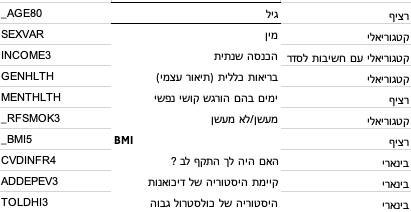

In [30]:
# --- Install required packages ---
!pip install pandas pyreadstat

# --- Import libraries ---
import pandas as pd
import pyreadstat

# --- Download BRFSS 2021 dataset from CDC and extract subset---
url = "https://www.cdc.gov/brfss/annual_data/2021/files/LLCP2021XPT.zip"

import requests, zipfile, io
r = requests.get(url)
z = zipfile.ZipFile(io.BytesIO(r.content))
z.extractall("brfss2021")

df, meta = pyreadstat.read_xport("brfss2021/LLCP2021.XPT ")

cols = [
    # Demographics
    "_AGE80", "SEXVAR", "INCOME3","_STATE",
    # Health behaviors & status
    "GENHLTH","MENTHLTH",
    "_RFSMOK3",
    # Anthropometrics
    "_BMI5",
    # Chronic conditions
    "CVDINFR4","DIABETE4",
    "ADDEPEV3", "TOLDHI3"
]
brfss_sub = df[cols].copy()

In [31]:

brfss_sub = brfss_sub[
    (brfss_sub['INCOME3'] != 77 ) &
    (brfss_sub['INCOME3'] != 99) &
    (brfss_sub['INCOME3'] != 'BLANK')
]


brfss_sub1 = brfss_sub[brfss_sub['_STATE'] == 36]


brfss_sub1


,_AGE80,SEXVAR,INCOME3,_STATE,GENHLTH,MENTHLTH,_RFSMOK3,_BMI5,CVDINFR4,DIABETE4,ADDEPEV3,TOLDHI3
254073,75.0,2.0,4.0,36.0,2.0,30.0,1.0,2622.0,2.0,4.0,2.0,1.0
254074,18.0,2.0,9.0,36.0,2.0,1.0,1.0,2080.0,2.0,3.0,2.0,2.0
254075,75.0,1.0,6.0,36.0,2.0,88.0,1.0,2673.0,2.0,3.0,2.0,2.0
254077,56.0,1.0,5.0,36.0,4.0,3.0,2.0,3261.0,2.0,3.0,1.0,1.0
254078,80.0,2.0,9.0,36.0,3.0,88.0,1.0,2271.0,2.0,3.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...
293163,33.0,2.0,4.0,36.0,3.0,15.0,2.0,4291.0,2.0,3.0,1.0,2.0
293164,24.0,1.0,6.0,36.0,2.0,2.0,1.0,2411.0,2.0,3.0,2.0,2.0
293165,40.0,2.0,7.0,36.0,2.0,17.0,1.0,2349.0,2.0,3.0,1.0,2.0
293166,62.0,2.0,6.0,36.0,3.0,88.0,2.0,2976.0,2.0,3.0,2.0,2.0


In [32]:

brfss_sub1 = brfss_sub1.drop(columns = ['_STATE'])
brfss_sub1

,_AGE80,SEXVAR,INCOME3,GENHLTH,MENTHLTH,_RFSMOK3,_BMI5,CVDINFR4,DIABETE4,ADDEPEV3,TOLDHI3
254073,75.0,2.0,4.0,2.0,30.0,1.0,2622.0,2.0,4.0,2.0,1.0
254074,18.0,2.0,9.0,2.0,1.0,1.0,2080.0,2.0,3.0,2.0,2.0
254075,75.0,1.0,6.0,2.0,88.0,1.0,2673.0,2.0,3.0,2.0,2.0
254077,56.0,1.0,5.0,4.0,3.0,2.0,3261.0,2.0,3.0,1.0,1.0
254078,80.0,2.0,9.0,3.0,88.0,1.0,2271.0,2.0,3.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
293163,33.0,2.0,4.0,3.0,15.0,2.0,4291.0,2.0,3.0,1.0,2.0
293164,24.0,1.0,6.0,2.0,2.0,1.0,2411.0,2.0,3.0,2.0,2.0
293165,40.0,2.0,7.0,2.0,17.0,1.0,2349.0,2.0,3.0,1.0,2.0
293166,62.0,2.0,6.0,3.0,88.0,2.0,2976.0,2.0,3.0,2.0,2.0


In [33]:


brfss_sub2 = brfss_sub1[
    (brfss_sub1['GENHLTH'] != 7) &
    (brfss_sub1['GENHLTH'] != 9) &
    (brfss_sub1['GENHLTH'] != 'BLANK')
]


brfss_sub2

,_AGE80,SEXVAR,INCOME3,GENHLTH,MENTHLTH,_RFSMOK3,_BMI5,CVDINFR4,DIABETE4,ADDEPEV3,TOLDHI3
254073,75.0,2.0,4.0,2.0,30.0,1.0,2622.0,2.0,4.0,2.0,1.0
254074,18.0,2.0,9.0,2.0,1.0,1.0,2080.0,2.0,3.0,2.0,2.0
254075,75.0,1.0,6.0,2.0,88.0,1.0,2673.0,2.0,3.0,2.0,2.0
254077,56.0,1.0,5.0,4.0,3.0,2.0,3261.0,2.0,3.0,1.0,1.0
254078,80.0,2.0,9.0,3.0,88.0,1.0,2271.0,2.0,3.0,2.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...
293163,33.0,2.0,4.0,3.0,15.0,2.0,4291.0,2.0,3.0,1.0,2.0
293164,24.0,1.0,6.0,2.0,2.0,1.0,2411.0,2.0,3.0,2.0,2.0
293165,40.0,2.0,7.0,2.0,17.0,1.0,2349.0,2.0,3.0,1.0,2.0
293166,62.0,2.0,6.0,3.0,88.0,2.0,2976.0,2.0,3.0,2.0,2.0


In [34]:
brfss_sub3 = brfss_sub2[
    (brfss_sub2['MENTHLTH'] != 77) &
    (brfss_sub2['MENTHLTH'] != 99) &
    (brfss_sub2['MENTHLTH'] != 88) &
    (brfss_sub2['MENTHLTH'] != 'BLANK')
]
brfss_sub3


,_AGE80,SEXVAR,INCOME3,GENHLTH,MENTHLTH,_RFSMOK3,_BMI5,CVDINFR4,DIABETE4,ADDEPEV3,TOLDHI3
254073,75.0,2.0,4.0,2.0,30.0,1.0,2622.0,2.0,4.0,2.0,1.0
254074,18.0,2.0,9.0,2.0,1.0,1.0,2080.0,2.0,3.0,2.0,2.0
254077,56.0,1.0,5.0,4.0,3.0,2.0,3261.0,2.0,3.0,1.0,1.0
254082,72.0,1.0,7.0,4.0,30.0,1.0,NaN,2.0,3.0,1.0,2.0
254083,53.0,1.0,8.0,4.0,10.0,1.0,3839.0,2.0,3.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...
293160,64.0,2.0,3.0,4.0,2.0,1.0,3411.0,2.0,1.0,2.0,1.0
293161,27.0,1.0,4.0,2.0,10.0,1.0,4161.0,2.0,3.0,1.0,2.0
293163,33.0,2.0,4.0,3.0,15.0,2.0,4291.0,2.0,3.0,1.0,2.0
293164,24.0,1.0,6.0,2.0,2.0,1.0,2411.0,2.0,3.0,2.0,2.0


In [35]:
brfss_sub4 = brfss_sub3[brfss_sub2['_RFSMOK3'] != 9]
brfss_sub4

/tmp/ipython-input-2469558662.py:1: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  brfss_sub4 = brfss_sub3[brfss_sub2['_RFSMOK3'] != 9]


,_AGE80,SEXVAR,INCOME3,GENHLTH,MENTHLTH,_RFSMOK3,_BMI5,CVDINFR4,DIABETE4,ADDEPEV3,TOLDHI3
254073,75.0,2.0,4.0,2.0,30.0,1.0,2622.0,2.0,4.0,2.0,1.0
254074,18.0,2.0,9.0,2.0,1.0,1.0,2080.0,2.0,3.0,2.0,2.0
254077,56.0,1.0,5.0,4.0,3.0,2.0,3261.0,2.0,3.0,1.0,1.0
254082,72.0,1.0,7.0,4.0,30.0,1.0,NaN,2.0,3.0,1.0,2.0
254083,53.0,1.0,8.0,4.0,10.0,1.0,3839.0,2.0,3.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...
293160,64.0,2.0,3.0,4.0,2.0,1.0,3411.0,2.0,1.0,2.0,1.0
293161,27.0,1.0,4.0,2.0,10.0,1.0,4161.0,2.0,3.0,1.0,2.0
293163,33.0,2.0,4.0,3.0,15.0,2.0,4291.0,2.0,3.0,1.0,2.0
293164,24.0,1.0,6.0,2.0,2.0,1.0,2411.0,2.0,3.0,2.0,2.0


In [36]:
brfss_sub5 = brfss_sub4[
    (brfss_sub4['CVDINFR4'] != 7) &
    (brfss_sub4['CVDINFR4'] != 9) &
    (brfss_sub4['CVDINFR4'] != 'BLANK')
]
brfss_sub5

,_AGE80,SEXVAR,INCOME3,GENHLTH,MENTHLTH,_RFSMOK3,_BMI5,CVDINFR4,DIABETE4,ADDEPEV3,TOLDHI3
254073,75.0,2.0,4.0,2.0,30.0,1.0,2622.0,2.0,4.0,2.0,1.0
254074,18.0,2.0,9.0,2.0,1.0,1.0,2080.0,2.0,3.0,2.0,2.0
254077,56.0,1.0,5.0,4.0,3.0,2.0,3261.0,2.0,3.0,1.0,1.0
254082,72.0,1.0,7.0,4.0,30.0,1.0,NaN,2.0,3.0,1.0,2.0
254083,53.0,1.0,8.0,4.0,10.0,1.0,3839.0,2.0,3.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...
293160,64.0,2.0,3.0,4.0,2.0,1.0,3411.0,2.0,1.0,2.0,1.0
293161,27.0,1.0,4.0,2.0,10.0,1.0,4161.0,2.0,3.0,1.0,2.0
293163,33.0,2.0,4.0,3.0,15.0,2.0,4291.0,2.0,3.0,1.0,2.0
293164,24.0,1.0,6.0,2.0,2.0,1.0,2411.0,2.0,3.0,2.0,2.0


In [37]:
brfss_sub6 = brfss_sub5[
    (brfss_sub5['DIABETE4'] != 7) &
    (brfss_sub5['DIABETE4'] != 9) &
    (brfss_sub5['DIABETE4'] != 'BLANK')
]
brfss_sub6

,_AGE80,SEXVAR,INCOME3,GENHLTH,MENTHLTH,_RFSMOK3,_BMI5,CVDINFR4,DIABETE4,ADDEPEV3,TOLDHI3
254073,75.0,2.0,4.0,2.0,30.0,1.0,2622.0,2.0,4.0,2.0,1.0
254074,18.0,2.0,9.0,2.0,1.0,1.0,2080.0,2.0,3.0,2.0,2.0
254077,56.0,1.0,5.0,4.0,3.0,2.0,3261.0,2.0,3.0,1.0,1.0
254082,72.0,1.0,7.0,4.0,30.0,1.0,NaN,2.0,3.0,1.0,2.0
254083,53.0,1.0,8.0,4.0,10.0,1.0,3839.0,2.0,3.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...
293160,64.0,2.0,3.0,4.0,2.0,1.0,3411.0,2.0,1.0,2.0,1.0
293161,27.0,1.0,4.0,2.0,10.0,1.0,4161.0,2.0,3.0,1.0,2.0
293163,33.0,2.0,4.0,3.0,15.0,2.0,4291.0,2.0,3.0,1.0,2.0
293164,24.0,1.0,6.0,2.0,2.0,1.0,2411.0,2.0,3.0,2.0,2.0


In [38]:
brfss_sub7 = brfss_sub6[
    (brfss_sub6['ADDEPEV3'] != 7) &
    (brfss_sub6['ADDEPEV3'] != 9) &
    (brfss_sub6['ADDEPEV3'] != 'BLANK')
]
brfss_sub7

,_AGE80,SEXVAR,INCOME3,GENHLTH,MENTHLTH,_RFSMOK3,_BMI5,CVDINFR4,DIABETE4,ADDEPEV3,TOLDHI3
254073,75.0,2.0,4.0,2.0,30.0,1.0,2622.0,2.0,4.0,2.0,1.0
254074,18.0,2.0,9.0,2.0,1.0,1.0,2080.0,2.0,3.0,2.0,2.0
254077,56.0,1.0,5.0,4.0,3.0,2.0,3261.0,2.0,3.0,1.0,1.0
254082,72.0,1.0,7.0,4.0,30.0,1.0,NaN,2.0,3.0,1.0,2.0
254083,53.0,1.0,8.0,4.0,10.0,1.0,3839.0,2.0,3.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...
293160,64.0,2.0,3.0,4.0,2.0,1.0,3411.0,2.0,1.0,2.0,1.0
293161,27.0,1.0,4.0,2.0,10.0,1.0,4161.0,2.0,3.0,1.0,2.0
293163,33.0,2.0,4.0,3.0,15.0,2.0,4291.0,2.0,3.0,1.0,2.0
293164,24.0,1.0,6.0,2.0,2.0,1.0,2411.0,2.0,3.0,2.0,2.0


In [39]:
brfss_sub8 = brfss_sub7[
    (brfss_sub7['TOLDHI3'] != 7) &
    (brfss_sub7['TOLDHI3'] != 9) &
    (brfss_sub7['TOLDHI3'] != 'BLANK')
]
brfss_sub8

,_AGE80,SEXVAR,INCOME3,GENHLTH,MENTHLTH,_RFSMOK3,_BMI5,CVDINFR4,DIABETE4,ADDEPEV3,TOLDHI3
254073,75.0,2.0,4.0,2.0,30.0,1.0,2622.0,2.0,4.0,2.0,1.0
254074,18.0,2.0,9.0,2.0,1.0,1.0,2080.0,2.0,3.0,2.0,2.0
254077,56.0,1.0,5.0,4.0,3.0,2.0,3261.0,2.0,3.0,1.0,1.0
254082,72.0,1.0,7.0,4.0,30.0,1.0,NaN,2.0,3.0,1.0,2.0
254083,53.0,1.0,8.0,4.0,10.0,1.0,3839.0,2.0,3.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...
293160,64.0,2.0,3.0,4.0,2.0,1.0,3411.0,2.0,1.0,2.0,1.0
293161,27.0,1.0,4.0,2.0,10.0,1.0,4161.0,2.0,3.0,1.0,2.0
293163,33.0,2.0,4.0,3.0,15.0,2.0,4291.0,2.0,3.0,1.0,2.0
293164,24.0,1.0,6.0,2.0,2.0,1.0,2411.0,2.0,3.0,2.0,2.0


In [40]:
brfss_sub_final = brfss_sub8.reset_index(drop=True)
brfss_sub_final

,_AGE80,SEXVAR,INCOME3,GENHLTH,MENTHLTH,_RFSMOK3,_BMI5,CVDINFR4,DIABETE4,ADDEPEV3,TOLDHI3
0,75.0,2.0,4.0,2.0,30.0,1.0,2622.0,2.0,4.0,2.0,1.0
1,18.0,2.0,9.0,2.0,1.0,1.0,2080.0,2.0,3.0,2.0,2.0
2,56.0,1.0,5.0,4.0,3.0,2.0,3261.0,2.0,3.0,1.0,1.0
3,72.0,1.0,7.0,4.0,30.0,1.0,NaN,2.0,3.0,1.0,2.0
4,53.0,1.0,8.0,4.0,10.0,1.0,3839.0,2.0,3.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...
9775,64.0,2.0,3.0,4.0,2.0,1.0,3411.0,2.0,1.0,2.0,1.0
9776,27.0,1.0,4.0,2.0,10.0,1.0,4161.0,2.0,3.0,1.0,2.0
9777,33.0,2.0,4.0,3.0,15.0,2.0,4291.0,2.0,3.0,1.0,2.0
9778,24.0,1.0,6.0,2.0,2.0,1.0,2411.0,2.0,3.0,2.0,2.0


In [41]:
brfss_sub_final = brfss_sub_final.dropna(subset=['_BMI5', 'TOLDHI3'])


In [42]:
random_5k_rows = brfss_sub_final.sample(n=5000, random_state=42)
random_5k_rows = random_5k_rows.reset_index(drop=True)
random_5k_rows.drop(columns=['DIABETE4'] ,inplace=True)
random_5k_rows

,_AGE80,SEXVAR,INCOME3,GENHLTH,MENTHLTH,_RFSMOK3,_BMI5,CVDINFR4,ADDEPEV3,TOLDHI3
0,26.0,1.0,8.0,2.0,2.0,1.0,2584.0,2.0,2.0,2.0
1,46.0,1.0,11.0,3.0,5.0,1.0,3499.0,2.0,2.0,2.0
2,74.0,1.0,10.0,2.0,5.0,1.0,2481.0,2.0,1.0,2.0
3,55.0,1.0,10.0,1.0,3.0,1.0,2580.0,2.0,2.0,2.0
4,51.0,1.0,9.0,3.0,2.0,1.0,2953.0,2.0,2.0,2.0
...,...,...,...,...,...,...,...,...,...,...
4995,80.0,1.0,6.0,4.0,30.0,1.0,2744.0,1.0,1.0,1.0
4996,25.0,1.0,8.0,2.0,20.0,1.0,2518.0,2.0,1.0,2.0
4997,72.0,1.0,5.0,4.0,30.0,1.0,1994.0,2.0,1.0,2.0
4998,73.0,2.0,7.0,3.0,5.0,1.0,2163.0,2.0,1.0,2.0


In [43]:
import pandas as pd


age_80_plus_count = random_5k_rows[random_5k_rows['_AGE80'] == 23].shape[0]
total_count = random_5k_rows.shape[0]
percentage = (age_80_plus_count / total_count) * 100

print(f"Total rows in random_5k_rows: {total_count}")
print(f"Respondents aged 80 or older: {age_80_plus_count}")
print(f"Percentage aged 80 or older: {percentage:.2f}%")



Total rows in random_5k_rows: 5000
Respondents aged 80 or older: 43
Percentage aged 80 or older: 0.86%


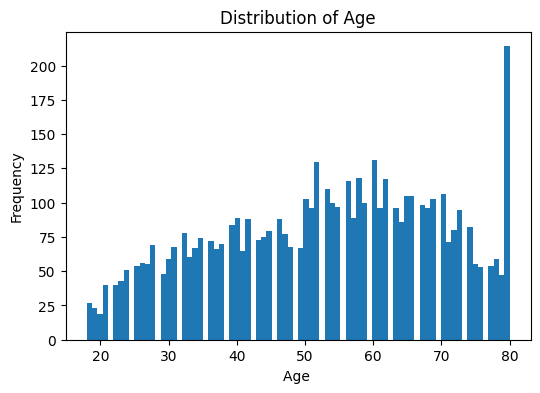

,_AGE80
count,5000.000000
mean,52.860800
std,16.472392
min,18.000000
25%,40.000000
50%,54.000000
75%,66.000000
max,80.000000


In [44]:
import matplotlib.pyplot as plt
age_col = random_5k_rows['_AGE80']


plt.figure(figsize=(6,4))
plt.hist(age_col, bins=80)
plt.title("Distribution of Age")
plt.xlabel("Age ")
plt.ylabel("Frequency")
plt.show()

age_col.describe()


We can see that the most common age is 80 and this is anomaly more than the others, and most of the sample's ages are between 50 and 70 years old.

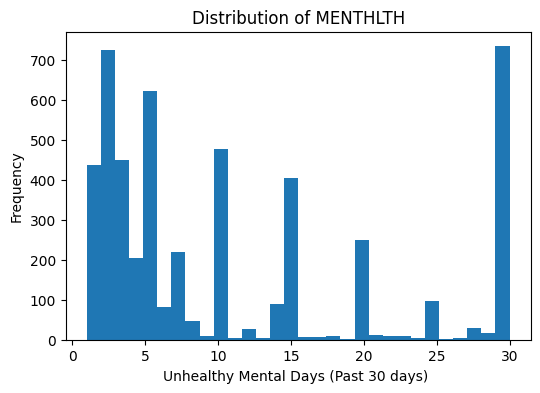

,MENTHLTH
count,5000.000000
mean,10.862200
std,10.028944
min,1.000000
25%,3.000000
50%,6.000000
75%,15.000000
max,30.000000


In [45]:
ment_col = random_5k_rows['MENTHLTH']


plt.figure(figsize=(6,4))
plt.hist(ment_col, bins=30)
plt.title("Distribution of MENTHLTH")
plt.xlabel("Unhealthy Mental Days (Past 30 days) ")
plt.ylabel("Frequency")
plt.show()

ment_col.describe()

The number of people reporting poor mental health generally decreases as the number of days increases, but the distribution shows a major spike in reports at 30 days. This pattern is best explained by the all-or-nothing thinking bias: when asked to quantify their experiences over 30 days, most respondents tend to simplify their answer by choosing the extreme categories reporting:
either 0 days (everything is good) or 30 days (everything is very bad).

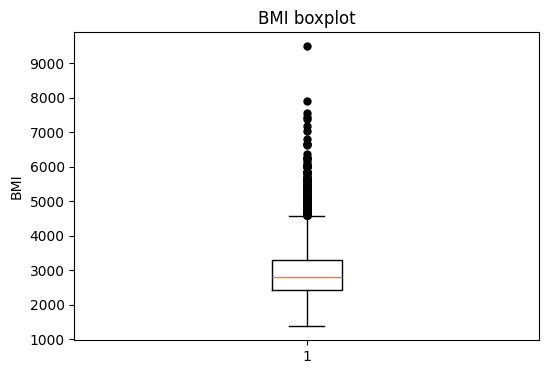

,_BMI5
count,5000.000000
mean,2946.457400
std,748.067828
min,1372.000000
25%,2433.000000
50%,2812.500000
75%,3292.000000
max,9494.000000


In [46]:
bmi_col = random_5k_rows['_BMI5']

bmi_col = pd.to_numeric(bmi_col, errors='coerce')

bmi_col = bmi_col.dropna()

plt.figure(figsize=(6,4))
plt.boxplot(
    bmi_col,
    showfliers=True,
    flierprops=dict(
        marker='o',
        markersize=5,
        markerfacecolor='black',
        markeredgecolor='black'
    )
)
plt.title("BMI boxplot")
plt.ylabel("BMI")
plt.show()

bmi_col.describe()



Here we can see that there are a lot of outliers in the high side, it means that specificly in New York there are a lot obese/overweight people.

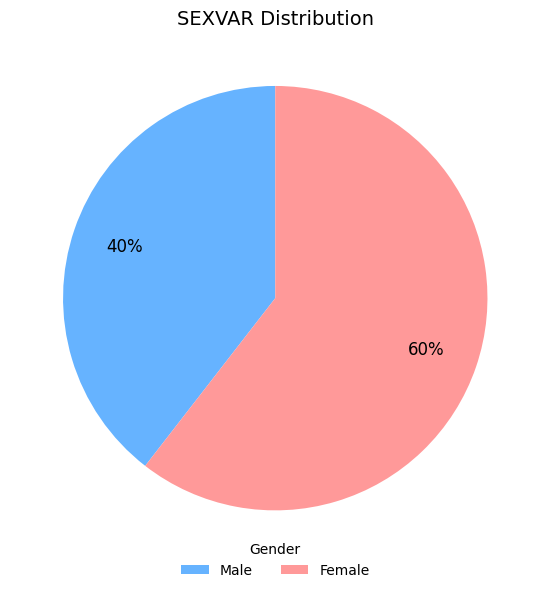

In [47]:
import matplotlib.pyplot as plt
import pandas as pd

sex_col = pd.to_numeric(random_5k_rows['SEXVAR'], errors='coerce').dropna()

mapping = {1: "Male", 2: "Female"}
sex_named = sex_col.map(mapping)

order = ["Male", "Female"]
counts = sex_named.value_counts().reindex(order).fillna(0)

colors = ["#66b3ff", "#ff9999"]
plt.figure(figsize=(6,6))
wedges, texts, autotexts = plt.pie(
    counts,
    autopct="%1.0f%%",
    startangle=90,
    colors=colors,
    textprops={'color': "black", 'fontsize': 12},
    pctdistance=0.75
)

plt.legend(
    wedges,
    counts.index,
    title="Gender",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=2,
    frameon=False
)

plt.title("SEXVAR Distribution", fontsize=14)
plt.tight_layout()
plt.show()

There are 20% more women than men in the sample, and this difference might affect some of our results. We will consider this when we do the rest of the analysis.*italicized text*

/tmp/ipython-input-2173423624.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


Bar plot saved as genhlth_barplot.png


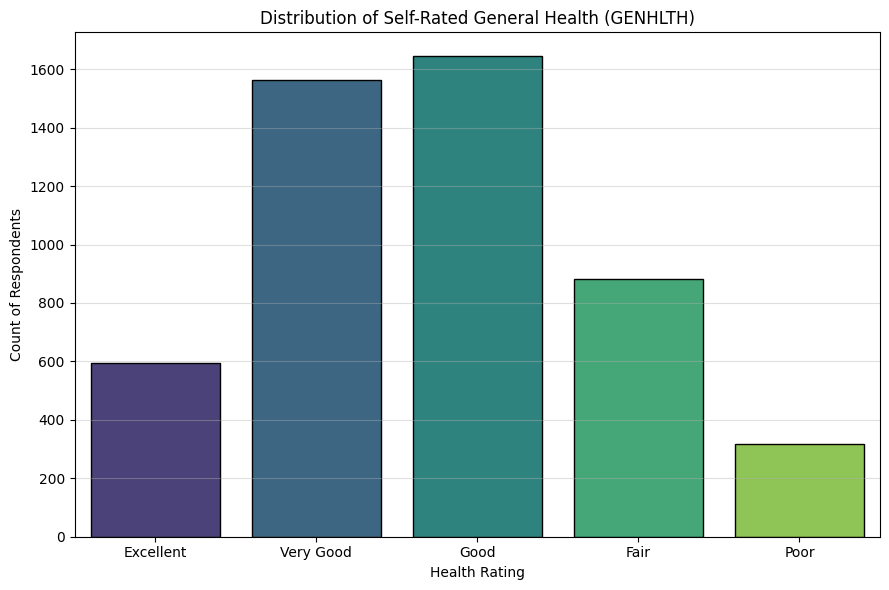

In [48]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

health_labels = {
    1.0: "Excellent",
    2.0: "Very Good",
    3.0: "Good",
    4.0: "Fair",
    5.0: "Poor"
}


random_5k_rows_copy = random_5k_rows.copy()
random_5k_rows_copy['HEALTH_RATING'] = random_5k_rows_copy['GENHLTH'].map(health_labels).astype('category')

order = list(health_labels.values())

plt.figure(figsize=(9, 6))

sns.countplot(
    x='HEALTH_RATING',
    data=random_5k_rows_copy,
    order=order,
    palette='viridis',
    edgecolor='black'
)

plt.title('Distribution of Self-Rated General Health (GENHLTH)')
plt.xlabel('Health Rating')
plt.ylabel('Count of Respondents')
plt.xticks(rotation=0)
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()

plt.savefig('genhlth_barplot.png')
print("Bar plot saved as genhlth_barplot.png")

we can see that the graph skewed to the left, which means most people rated their health as good the bars are highest at "Good" and "Very Good." The data has a long tail going towards the "Poor" rating, this just shows that most of the people in the sample think their health is pretty good.

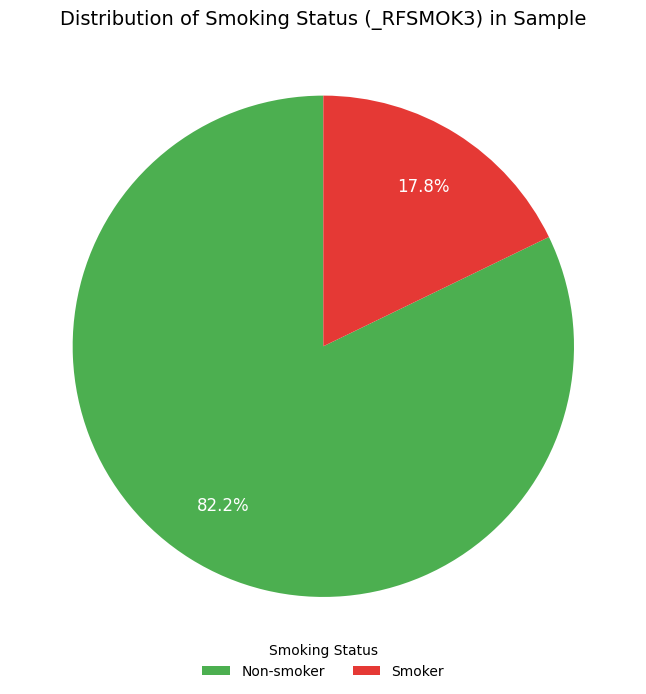

In [49]:
import matplotlib.pyplot as plt
import pandas as pd



smoker_col = pd.to_numeric(random_5k_rows['_RFSMOK3'], errors='coerce').dropna()

mapping = {1.0: "Non-smoker", 2.0: "Smoker"}
smoker_named = smoker_col.map(mapping)

order = ["Non-smoker", "Smoker"]
counts = smoker_named.value_counts().reindex(order).fillna(0)

colors = ["#4CAF50", "#E53935"]

plt.figure(figsize=(7,7))
wedges, texts, autotexts = plt.pie(
    counts,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    textprops={'color': "white", 'fontsize': 12},
    pctdistance=0.75
)

plt.legend(
    wedges,
    counts.index,
    title="Smoking Status",
    loc="lower center",
    bbox_to_anchor=(0.5, -0.05),
    ncol=2,
    frameon=False
)

plt.title("Distribution of Smoking Status (_RFSMOK3) in Sample", fontsize=14)
plt.tight_layout()
plt.show()

There are close to 4 times more Non-smokers than smokers in the sample, and this difference might affect some of our results. We will consider this when we do the rest of the analysis.

/tmp/ipython-input-683111991.py:27: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


Bar plot saved as income_barplot.png


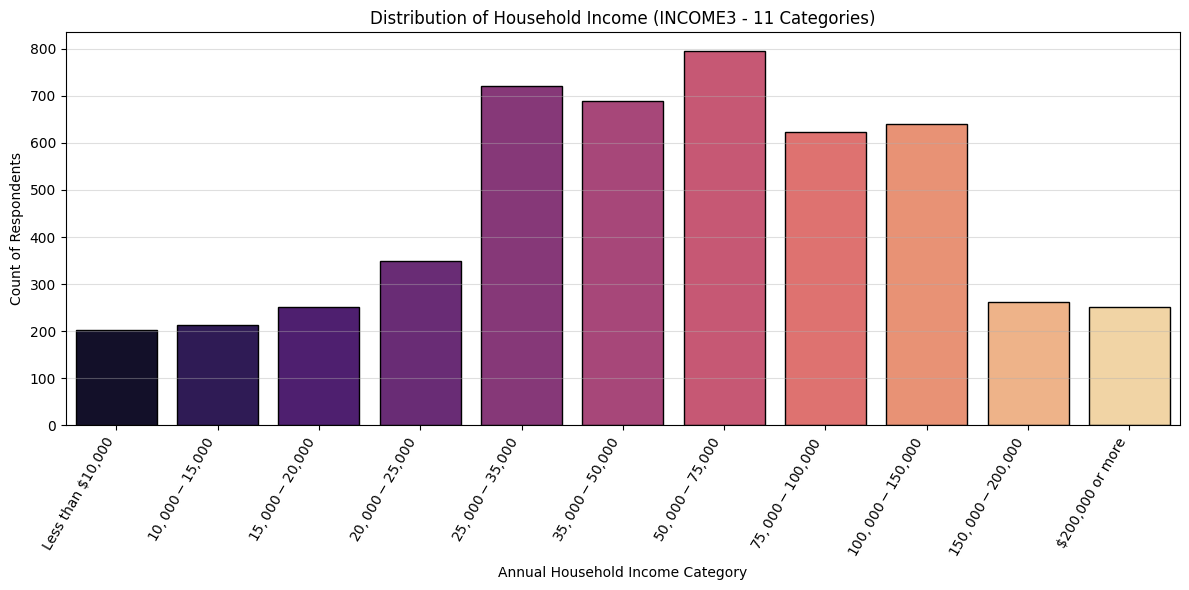

In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

income_labels = {
    1.0: "Less than $10,000",
    2.0: "$10,000 -  $15,000",
    3.0: "$15,000  -  $20,000",
    4.0: "$20,000  -  $25,000",
    5.0: "$25,000  -  $35,000",
    6.0: "$35,000  -  $50,000",
    7.0: "$50,000  -  $75,000",
    8.0: "$75,000  -  $100,000",
    9.0: "$100,000  - $150,000",
    10.0: "$150,000  - $200,000",
    11.0: "$200,000 or more"
}


random_5k_rows_copy = random_5k_rows.copy()

random_5k_rows_copy['INCOME_RATING'] = random_5k_rows_copy['INCOME3'].map(income_labels).astype('category')

order = list(income_labels.values())

plt.figure(figsize=(12, 6))
sns.countplot(
    x='INCOME_RATING',
    data=random_5k_rows_copy,
    order=order,
    palette='magma',
    edgecolor='black'
)

plt.title('Distribution of Household Income (INCOME3 - 11 Categories)')
plt.xlabel('Annual Household Income Category')
plt.ylabel('Count of Respondents')
plt.xticks(rotation=60, ha='right')
plt.grid(axis='y', alpha=0.4)
plt.tight_layout()

plt.savefig('income_barplot.png')
print("Bar plot saved as income_barplot.png")

The income graph shows a distribution that is not normal and is slightly skewed to the right. Most respondents are clustered in the middle-to-upper income brackets, with the largest group earning between 50,000 - 75,000 usd, and the second largest between 25,000 - 35,000 usd.

# Research questions

A. Does a high BMI lead to increase in the number of days people feel poor mental health?

This is a regression question whose continuous explanatory variable is _BMI5 and whose continuous explained variable is MENTHLTH.

B. Does an increase in a person's age lead to an increase in the probability of having high cholesterol?

This is a regression question whose continuous explanatory variable is _AGE80 and whose binary explained variable is TOLDHI3.

C. Is there a statistically significant difference in the BMI between individuals who have ever been told they had a heart attack and those who have not?

This is the test question where the continuous variable is _BMI5 and the binary variable is CVDINFR4.

More research questions:
1. Does a person's annual income category affect their chance of having depression?

2. Does increasing age affect the chance of having depression?